# 準備 Training Data

# 1. 安裝與 import

In [1]:
!pip install -q datasets opencv-python-headless

import cv2
import numpy as np
from PIL import Image
from datasets import load_dataset
import os
from IPython.display import display
import json

# 2. 載入資料
人臉

載 500 筆

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/450 [00:00<?, ?B/s]

收集到 500 張人臉圖片


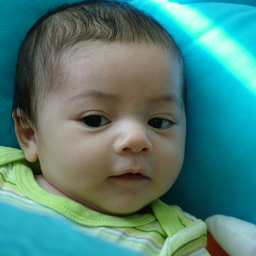

In [2]:
os.makedirs("training_data_morph/conditioning_images", exist_ok=True)
os.makedirs("training_data_morph/images", exist_ok=True)

# streaming=True 避免把整個資料集（5GB）全下載
ds_full = load_dataset("merkol/ffhq-256", split="train", streaming=True)

face_images = []
for sample in ds_full:
    face_images.append(sample["image"])
    if len(face_images) >= 500:
        break

print(f"收集到 {len(face_images)} 張人臉圖片")
display(face_images[0])

# 3. 生成 sketch 並存檔

In [8]:
def photo_to_sketch(pil_image):
    img = np.array(pil_image.convert("RGB").resize((512, 512)))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = np.ones((3, 3), np.uint8)
    gradient = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel)
    _, edges = cv2.threshold(gradient, 20, 255, cv2.THRESH_BINARY)
    edges_inv = cv2.bitwise_not(edges)
    sketch = cv2.cvtColor(edges_inv, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(sketch)

for i, photo in enumerate(face_images):
    photo_resized = photo.convert("RGB").resize((512, 512))
    sketch = photo_to_sketch(photo_resized)
    photo_resized.save(f"training_data_morph/images/{i:04d}.png")
    sketch.save(f"training_data_morph/conditioning_images/{i:04d}.png")
    if i % 20 == 0:
        print(f"Processed {i}/500")

print("存檔完成！")

Processed 0/500
Processed 20/500
Processed 40/500
Processed 60/500
Processed 80/500
Processed 100/500
Processed 120/500
Processed 140/500
Processed 160/500
Processed 180/500
Processed 200/500
Processed 220/500
Processed 240/500
Processed 260/500
Processed 280/500
Processed 300/500
Processed 320/500
Processed 340/500
Processed 360/500
Processed 380/500
Processed 400/500
Processed 420/500
Processed 440/500
Processed 460/500
Processed 480/500
存檔完成！


# 4. 確認一對 pair

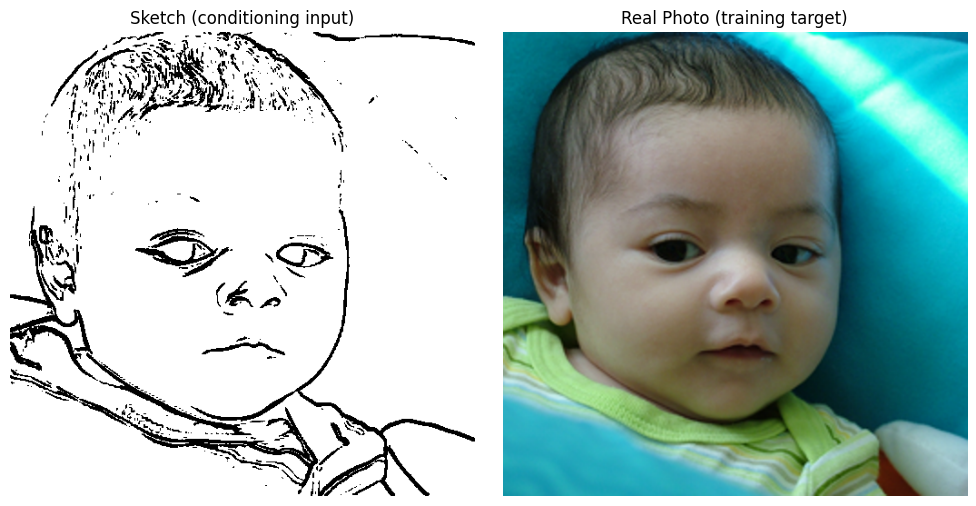

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(Image.open("training_data_morph/conditioning_images/0000.png"))
axes[0].set_title("Sketch (conditioning input)")
axes[0].axis("off")
axes[1].imshow(Image.open("training_data_morph/images/0000.png"))
axes[1].set_title("Real Photo (training target)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# 5. 建立 metadata.jsonl

In [15]:
with open("training_data_morph/train.jsonl", "w") as f:
    for i in range(len(face_images)):
        entry = {
            "image": f"images/{i:04d}.png",
            "conditioning_image": f"conditioning_images/{i:04d}.png",
            "text": "a person, photorealistic, high quality, detailed skin"
        }
        f.write(json.dumps(entry) + "\n")

print(f"metadata 建立完成，共 {len(face_images)} 筆")

# 確認格式正確
with open("training_data_morph/train.jsonl") as f:
    print("第一行：", f.readline())

metadata 建立完成，共 500 筆
第一行： {"image": "images/0000.png", "conditioning_image": "conditioning_images/0000.png", "text": "a person, photorealistic, high quality, detailed skin"}



# 6. 把資料存到 google drive
記得改成自己的路徑

In [16]:
import shutil, os
from google.colab import drive
drive.mount('/content/drive')

# 如果 Drive 上舊的資料夾存在，先刪掉再複製
drive_path = "/content/drive/MyDrive/++DL/04_project_face/training_data_morph"
if os.path.exists(drive_path):
    shutil.rmtree(drive_path)

shutil.copytree("training_data_morph", drive_path)
print("500 筆備份完成！")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
500 筆備份完成！


In [ ]:
# 重新掛載 Drive，把資料複製回來
# 這裡也記得改成自己的路徑
'''
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    "/content/drive/MyDrive/++DL/04_project_face/training_data",
    "training_data"
)
print("資料還原完成！")
'''